# old_main.ROI workflow with PixelTable

This notebook initializes `old_main.ROI` from a `PixelTable` (following the same pattern as `fermifit.ipynb`), fits a source, plots its SED, localizes it, and makes a TS map.

In [1]:
%reset -f
from importlib import reload
from pathlib import Path
import sys, types

import matplotlib.pyplot as plt
import numpy as np
from astropy.coordinates import SkyCoord
import astropy.wcs  # ensure astropy.wcs namespace exists for old_main
import astropy.io.fits.verify  # ensure astropy.io.fits.verify exists

# Force imports to use this workspace copy of like3.
workspace_root = Path('/home/burnett/work/pixel-table').resolve()
if str(workspace_root) not in sys.path:
    sys.path.insert(0, str(workspace_root))

from like3 import pixel_table as pixel_table_mod
reload(pixel_table_mod)
PixelTable = pixel_table_mod.PixelTable

from like3 import sourcelist as sourcelist_mod
reload(sourcelist_mod)
SourceModel = sourcelist_mod.SourceModel

from like3.skydir import SkyDir as _Like3SkyDir
from like3 import quadform as _like3_quadform
from like3.utilities import keyword_options as _keyword_options



from like3 import views as views_mod
from like3 import old_main as old_main_mod
reload(views_mod)
reload(old_main_mod)
ROI = old_main_mod.ROI
print('Using old_main from:', old_main_mod.__file__)

ModuleNotFoundError: No module named 'like3.plotting.skydir'

In [ ]:
# Match the source-model construction approach used in fermifit.ipynb
roi_name, cone_size = 'Geminga', 1.0
roi_center = SkyCoord.from_name(roi_name)
roi_sources = SourceModel.from_fermi_catalog(
    'v40',
    skydir=roi_center,
    cone_size=cone_size,
    query='significance >= 25',
)

print(f'Loaded {len(roi_sources)} sources around {roi_name}')
selected_name = str(roi_sources.source_names[0])
print('Selected source:', selected_name)

Loaded Fermi 4FGL gll_psc_v40.fit: 7224 entries
Loaded 1 sources around Geminga
Selected source: FL16Y J0633.9+1746


In [ ]:
# Initialize PixelTable and ROI
pixel_path = Path('files/kerr/toby_v4.fits')
assert pixel_path.exists(), f'Missing PixelTable FITS file: {pixel_path}'

pt = PixelTable(str(pixel_path), source_model=roi_sources)
roi = ROI(pt)

print('ROI initialized with', len(roi.sources), 'sources')

Loaded pixel table from "files/kerr/toby_v4.fits":
            42 bands Band(0, np.int64(4)): PSF0@1.33 GeV nside 64 occ 1.001 ... Band(3, np.int64(11)): PSF3@74.99 GeV nside 2048 occ 0.000
            193,317,496 photons
            8,240,918 pixels, order ring
            
Attached source model with 1 sources to pixel table
set_psf: 72 PSF entries (FRONT, BACK, PSF0, PSF1, PSF2, PSF3) from 'files/loc'
ROI initialized with 1 sources


In [ ]:
# Fit the selected source (PixelTable fit is the stable path)
import io
from contextlib import redirect_stdout

target_name = str(selected_name)

# First try gradient-based fit, but capture internal optimizer chatter.
buf = io.StringIO()
with redirect_stdout(buf):
    fit_out = pt.fit(select=target_name, use_gradient=True, quiet=True)
fit_log = buf.getvalue()

# If the optimizer reported an internal fit failure, retry with a robust fallback.
if 'Fit failure' in fit_log:
    fit_out = pt.fit(select=target_name, method='powell', use_gradient=False, quiet=True)
    print('Primary optimizer reported Fit failure; fallback (powell) was used.')

# PixelTable.fit is expected to return (fit_val, pars, errs), but handle
# legacy/alternate return objects to avoid unpacking TypeError.
if isinstance(fit_out, (tuple, list)) and len(fit_out) >= 3:
    fit_val, pars, errs = fit_out[0], fit_out[1], fit_out[2]
elif hasattr(fit_out, 'fun') and hasattr(fit_out, 'x'):
    fit_val, pars = float(fit_out.fun), fit_out.x
    errs = getattr(pt, 'fit_info', {}).get('sigs', None)
else:
    raise TypeError(f'Unexpected fit return type: {type(fit_out)}')

src = roi.get_source(target_name)
print(f'Fit complete for {src.name}')
print('fit_val =', fit_val)
print('pars =', pars)
print('errs =', errs)

Fit complete for FL16Y J0633.9+1746
fit_val = -341.6455927938223
pars = [-9.54197761  2.03727764]
errs = [0.00057743 0.0010696 ]


Computed 12 SED bins
[( 100.        ,  177.827941  , 1.26870976e-08, 1.26375594e-08, 1.27368299e-08,  166521.34727608)
 ( 177.827941  ,  316.22776602, 6.26570188e-09, 6.24630176e-09, 6.28516226e-09,  371415.21039564)
 ( 316.22776602,  562.34132519, 3.00305157e-09, 2.99626023e-09, 3.00985831e-09,  913926.74872052)
 ( 562.34132519, 1000.        , 1.30899973e-09, 1.30603238e-09, 1.31197381e-09, 1268394.98808871)
 (1000.        , 1778.27941004, 4.74532945e-10, 4.73503890e-10, 4.75564237e-10, 1646505.47173731)]


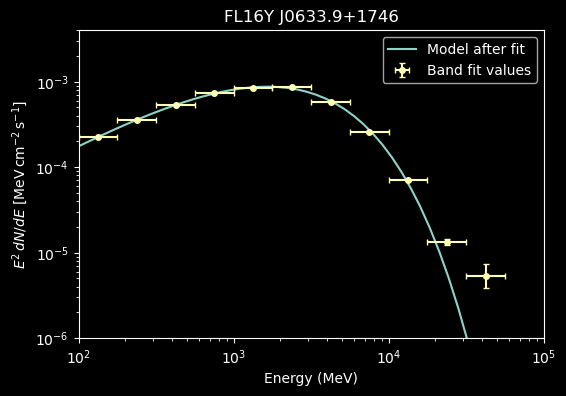

In [ ]:
# Generate SED plot with per-band flux points from ROI.get_sed (PixelTable backend)
target_name = str(selected_name)
sedrec = roi.get_sed(target_name, update=True)

print('Computed', len(sedrec), 'SED bins')
print(sedrec[['elow', 'ehigh', 'flux', 'lflux', 'uflux', 'ts']][:5])

# Apply dark background style
with plt.style.context('dark_background'):

    roi.plot_sed(target_name, size=(6, 4), ylim=(1e-6, 4e-3),)
    plt.show()

In [ ]:
b = roi[3,4]
b.diffuse[b._fit_mask]

array([7.1253595, 6.9235153, 6.7168727, 6.642443 , 6.645552 , 6.5943418,
       6.608035 , 6.867333 , 6.654198 , 6.748606 , 6.474488 , 6.553704 ,
       6.5775976, 6.355412 , 6.4080443, 6.7291694, 6.8610225, 6.8158503,
       7.117788 , 7.472968 , 7.6285853, 6.869936 , 7.339486 , 6.718009 ,
       7.1414843, 7.650453 , 7.6823826, 7.362061 , 7.243892 , 7.344885 ,
       6.7709813, 6.8865237, 6.349156 , 5.7769628, 6.9365187, 7.243083 ,
       6.8346615, 7.1198273, 6.7795515, 6.8985977, 6.600921 , 6.5718803,
       6.2674546, 6.48777  , 6.1780467, 6.094971 , 6.103323 , 5.9704714,
       5.9175043, 6.4640894, 6.158402 , 6.294991 , 5.9956937, 5.928927 ,
       5.8427687, 5.759911 , 5.6505847, 6.330816 , 6.1052165, 6.01383  ,
       5.727878 , 5.779896 , 5.5194263, 5.5265555, 5.437413 , 5.3555374,
       5.299029 , 5.682031 , 5.4194756, 5.6469007, 5.3916054, 5.256729 ,
       5.2147617, 5.2229466, 5.1644955, 6.3225627, 6.605871 , 6.0025105,
       6.141877 , 6.717603 , 6.6152797, 6.2108455, 

In [ ]:
# Localize the source with PixelTable localization view
target_name = str(selected_name)
loc = pt.localize(target_name, sigma=0.1, verbose=True)
src = roi.get_source(target_name)

# Keep source model position in sync, always as SkyCoord for PixelTable likelihood paths.
if hasattr(loc, 'dir') and loc.dir is not None:
    src.skydir = loc.dir.coord if hasattr(loc.dir, 'coord') else loc.dir

print('Localization result object:', loc)
print('Localized position:', getattr(loc, 'dir', None))

NameError: name 'selected_name' is not defined

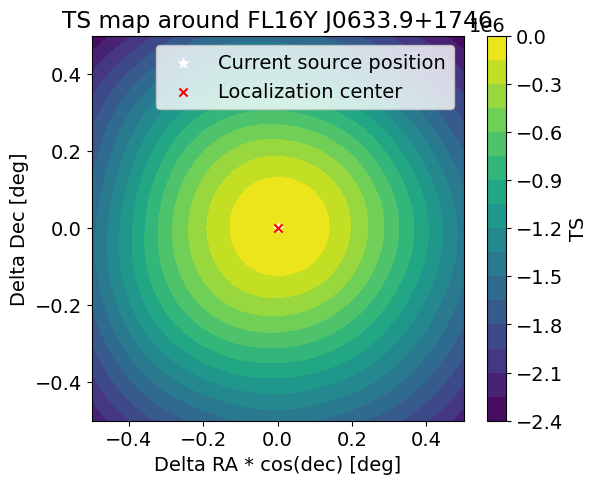

In [ ]:
# Generate a TS map around the source and overlay localization center
target_name = str(selected_name)
src = roi.get_source(target_name)

def _to_skycoord(obj):
    if hasattr(obj, 'coord'):
        return obj.coord
    return obj

center = _to_skycoord(src.skydir)
ra0, dec0 = center.ra.deg, center.dec.deg

size_deg = 0.5
nside = 41
dra = np.linspace(-size_deg, size_deg, nside)
ddec = np.linspace(-size_deg, size_deg, nside)
cosdec = np.cos(np.radians(dec0))
cosdec = cosdec if abs(cosdec) > 1e-6 else 1e-6

ll0 = pt.loglike()
ts_grid = np.zeros((nside, nside), dtype=float)
for iy, dy in enumerate(ddec):
    for ix, dx in enumerate(dra):
        ra = ra0 + dx / cosdec
        dec = dec0 + dy
        trial = SkyCoord(ra=ra, dec=dec, unit='deg', frame='icrs')
        ts_grid[iy, ix] = 2.0 * (pt.loglike(skydir=trial) - ll0)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.contourf(dra, ddec, ts_grid, levels=20, cmap='viridis')
ax.scatter([0], [0], c='white', s=50, marker='*', label='Current source position')

if hasattr(loc, 'dir') and loc.dir is not None:
    loc_sc = _to_skycoord(loc.dir)
    ax.scatter([(loc_sc.ra.deg - ra0) * cosdec], [loc_sc.dec.deg - dec0], c='red', s=35, marker='x', label='Localization center')

ax.set_xlabel('Delta RA * cos(dec) [deg]')
ax.set_ylabel('Delta Dec [deg]')
ax.set_title(f'TS map around {target_name}')
ax.legend(loc='best')
fig.colorbar(im, ax=ax, label='TS')
plt.show()
